In [2]:
%%capture
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('../utils')

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from reporting import performance_report
from metrics import get_annualized_mean_return, get_drawdown, get_periodic_correlation, get_correlation_std_error
from plotting import set_date_ticks
from optimization import get_portfolio_stats, solve_min_variance, solve_max_sharpe, build_efficient_frontier

plt.style.use('../utils/plot-style.rc')

In [4]:
prices_daily   = pd.read_parquet('./data/daily-etf-prices.parquet')
prices_monthly = pd.read_parquet('./data/monthly-etf-prices.parquet')
rfr_monthly    = pd.read_parquet('./data/monthly-rfr.parquet')

returns_daily   = prices_daily.pct_change().dropna(how='all')
returns_monthly = prices_monthly.pct_change().dropna(how='all')
excess_returns  = returns_monthly - rfr_monthly.values.reshape(-1,1)

## All US Equity (SPY)
Before any optimization let's take a baseline of a passive ETF investor that just holds a portfolio of large cap US equities with the SPY ETF. Returns are strong but also see quite a bit of volatility and very big drawdown in 2008.

     CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
--------------------------------------------------------
SPY   10.68        14.87            -50.78        0.65  


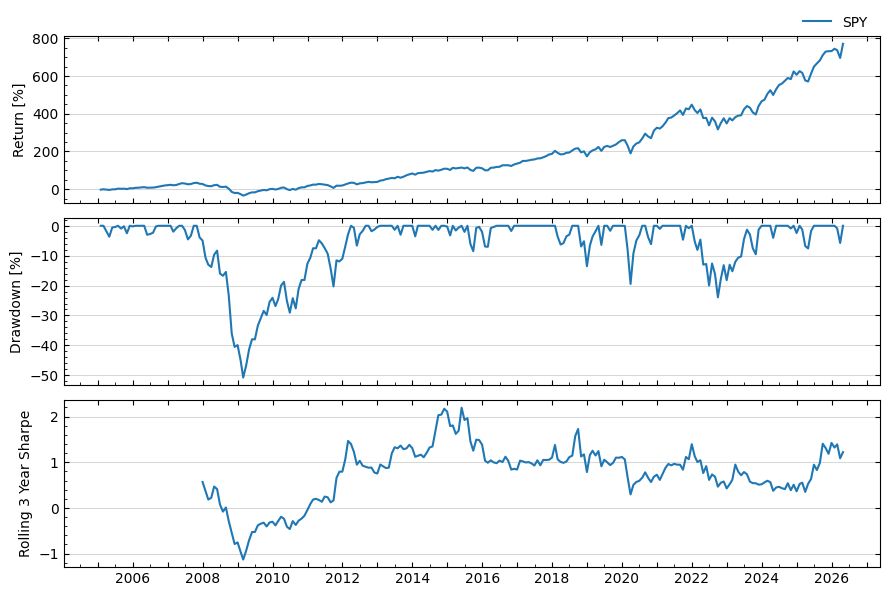

In [5]:
_ = performance_report(returns_monthly[['SPY']], risk_free_returns=rfr_monthly)

## Define a Universe of Assets
Can we do better by instead holding a more diversified portfolio of assets? Let's see. We can use a few ETFs to represent different asset classes a retail investor has access to. As part of the optimization we need to be able to estimate correlations / covariances. We are using return data at a monthly time scale however to improve our estimate of covariance we use daily data to have more samples. This is demonstrated in the correlation heatmaps shown below.

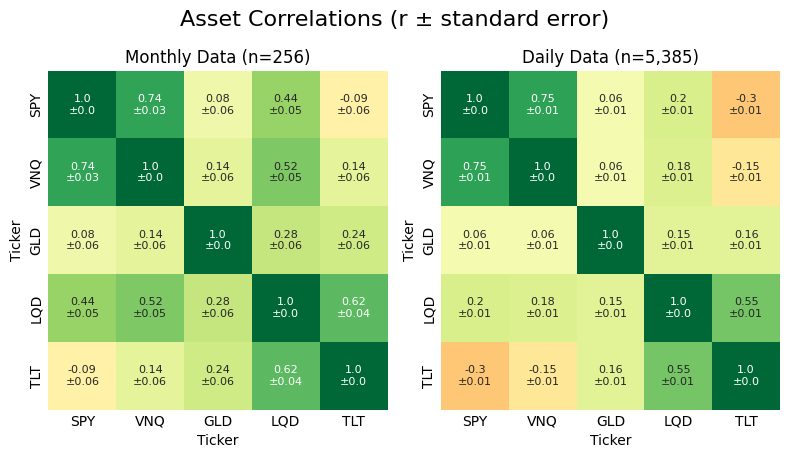

In [6]:
universe     = ['SPY', 'VNQ', 'GLD', 'LQD', 'TLT']

corr_monthly  = returns_monthly[universe].corr()
se_monthly    = get_correlation_std_error(returns_monthly[universe])
annot_monthly = corr_monthly.round(2).astype(str) + '\n±' + se_monthly.round(2).astype(str)

corr_daily   = returns_daily[universe].corr()
se_daily     = get_correlation_std_error(returns_daily[universe])
annot_daily  = corr_daily.round(2).astype(str) + '\n±' + se_daily.round(2).astype(str)

fig, axs = plt.subplots(ncols=2, figsize=(8, 4.5))

sns.heatmap(corr_monthly, vmax=1, vmin=-1, square=True, cbar=False, cmap='RdYlGn',
            annot=annot_monthly, fmt='', annot_kws={'fontsize': 8}, ax=axs[0])
axs[0].set_title(f'Monthly Data (n={len(returns_monthly):,})')
axs[0].tick_params(axis='both', length=0)

sns.heatmap(corr_daily, vmax=1, vmin=-1, square=True, cbar=False, cmap='RdYlGn',
            annot=annot_daily, fmt='', annot_kws={'fontsize': 8}, ax=axs[1])
axs[1].set_title(f'Daily Data (n={len(returns_daily):,})')
axs[1].tick_params(axis='both', length=0)

fig.suptitle('Asset Correlations (r ± standard error)')
fig.tight_layout()
plt.show()

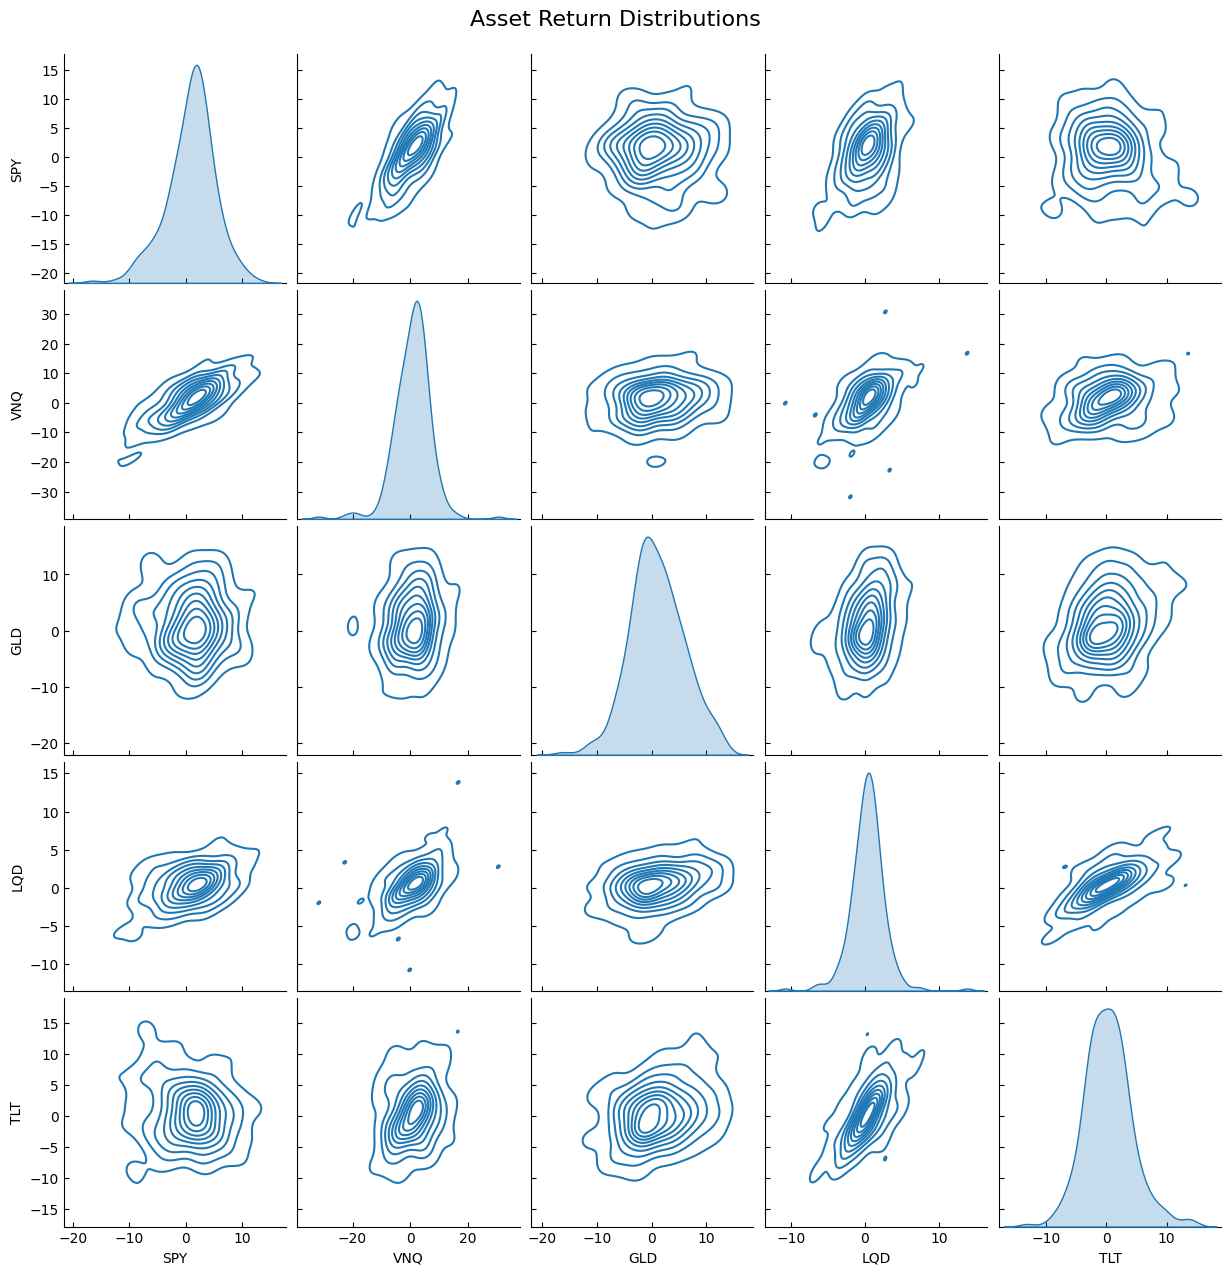

In [7]:
# also visualize all the return distributions as a pairplot
g = sns.pairplot(returns_monthly[universe] * 100., kind='kde')
g.figure.suptitle('Asset Return Distributions', y=1.02)
plt.show()

### Do Correlations Hold Up in a Crisis?

The correlation matrix above is calculated over the full sample, and calm periods dominate that sample. But in a genuine equity sell-off - a broad flight-to-quality/liquidity crunch - most risk assets tend to get pulled down together, so correlations to equities can rise sharply right when diversification would matter most.

To check this, look at each asset's rolling correlation to SPY next to SPY's own drawdown - correlations should visibly climb during major equity drawdowns like 2008 and 2020, showing that "diversifying" assets diversify less exactly when it counts.

Also we can see an important regime change from ~2022 onwards where the correlations of long term treasuries (TLT) and corporate bonds (LQD) with US large cap equities (SPY) jump significantly higher to above 0.5. In this case they are no longer the "divesified" assets they were from 2005 to 2022. For most of the 2005–2021 period, the primary macro risk driving markets was growth risk (recession fears, demand shocks, financial crises). In that regime stocks and bonds move in opposite directions. From 2022 onward, inflation risk became the dominant driver.

This is another a key observation because mean-variance optimization assumes that the covariance matrix is stable over time which it is clearly not!

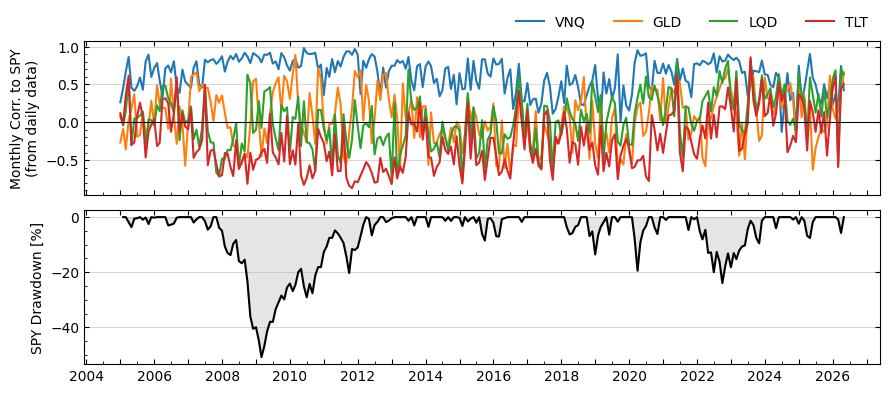

In [9]:
monthly_corr_from_daily = get_periodic_correlation(returns_daily[universe], 'SPY', freq='ME').drop(columns=['SPY'])
spy_drawdown            = get_drawdown(returns_monthly[['SPY']])['SPY']

fig, axs = plt.subplots(nrows=2, figsize=(9, 4), sharex=True)

ax = axs[0]
for ticker in monthly_corr_from_daily.columns:
    ax.plot(monthly_corr_from_daily[ticker], label=ticker)
ax.axhline(0, color='k', linewidth=0.75)
ax.set_ylabel('Monthly Corr. to SPY\n(from daily data)')
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.25), ncols=4, frameon=False)

ax = axs[1]
ax.plot(spy_drawdown * 100., color='k')
ax.fill_between(spy_drawdown.index, spy_drawdown * 100., 0, color='k', alpha=0.1)
ax.set_ylabel('SPY Drawdown [%]')

for ax in axs:
    set_date_ticks(ax)
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(top=True, bottom=True, left=True, right=True)
    ax.grid(axis='y', linewidth=0.75, alpha=0.5)

fig.tight_layout()
plt.show()

In [10]:
portfolio_name    = 'STOCK_BOND'
portfolio_weights = {'SPY' : 0.6,
                     'LQD' : 0.4,
                     }

if sum(list(portfolio_weights.values())) != 1:
    raise ValueError('Portfolio weights don\'t sum to 1!')

portfolio_returns = returns_monthly.mul(pd.Series(portfolio_weights)).sum(axis=1)
portfolio_returns = pd.DataFrame(portfolio_returns, columns=[portfolio_name])

stock_bond_df = returns_monthly[['SPY', 'LQD']].copy()
stock_bond_df = stock_bond_df.join(portfolio_returns)

## Efficient Frontier

Instead of picking portfolio weights by hand (like the 60/40 above), mean-variance optimization looks for the portfolio that minimizes risk (volatility) for a given level of expected return, across the full ETF universe. Sweeping across return levels traces out the *efficient frontier*.

The catch: mean-variance optimization needs a **forward-looking expected return** for each asset, not a historical one. We don't have a forecast, so as a stand-in we use each asset's historical sample mean return. This is a common simplification, but it's worth being upfront that it's a fairly noisy estimator (more below) - it's a stand-in for a real return forecast, not one itself.

In [11]:
mean_returns = get_annualized_mean_return(returns_monthly[universe])
cov_matrix   = returns_daily[universe].cov() * 252
rf_rate      = rfr_monthly['RF'].mean() * 12

### How Noisy Are These Mean Return Estimates?

Roughly ~20 years of monthly data isn't much to pin down a mean return - the standard error of the estimate is often as large as the differences between assets' mean returns, which means the optimizer below is partly reacting to estimation noise, not real differences in expected return.

In [12]:
n_obs     = len(returns_monthly[universe])
std_error = (returns_monthly[universe].std() / np.sqrt(n_obs)) * 12  # annualized standard error of the mean

mean_estimate_df = pd.DataFrame({'Mean Return [%]' : mean_returns * 100,
                                 'Std Error [%]'   : std_error * 100,
                                 }).sort_values('Mean Return [%]', ascending=False)

print(mean_estimate_df.round(2))

        Mean Return [%]  Std Error [%]
Ticker                                
GLD               12.06           3.70
SPY               11.30           3.22
VNQ                9.11           4.68
LQD                4.21           1.71
TLT                4.00           2.96


### Optimize Based on MOSEK Portfolio Optimization Cookbook
Using the same notation as the MOSEK cookbook:
- Vector of asset weights $x$
- Vector of expected returns $\mu$
- Covariance matrix $\Sigma$
- Risk-free rate $r_f$

We'll create the following portfolios:

**Global Minimum Variance**: the lowest-volatility portfolio, ignoring expected return entirely:

$$
\begin{aligned}
\text{minimize} \quad & x^\mathrm{T}\Sigma x \\
\text{subject to} \quad & \mathbf{1}^\mathrm{T}x = 1, \quad x \geq 0
\end{aligned}
$$

**Efficient Frontier point**: the lowest-volatility portfolio for a given target return $\mu_\mathrm{target}$ (sweeping $\mu_\mathrm{target}$ traces out the frontier):

$$
\begin{aligned}
\text{minimize} \quad & x^\mathrm{T}\Sigma x \\
\text{subject to} \quad & \mathbf{1}^\mathrm{T}x = 1, \quad \mu^\mathrm{T}x = \mu_\mathrm{target}, \quad x \geq 0
\end{aligned}
$$

**Maximum Sharpe Ratio (Tangency Portfolio)**: the portfolio maximizing risk-adjusted excess return:

$$
\begin{aligned}
\text{maximize} \quad & \dfrac{\mu^\mathrm{T}x - r_f}{\sqrt{x^\mathrm{T}\Sigma x}} \\
\text{subject to} \quad & \mathbf{1}^\mathrm{T}x = 1, \quad x \geq 0
\end{aligned}
$$

In [13]:
gmv_weights    = solve_min_variance(mean_returns, cov_matrix)
sharpe_weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)

gmv_return, gmv_vol       = get_portfolio_stats(gmv_weights, mean_returns, cov_matrix)
sharpe_return, sharpe_vol = get_portfolio_stats(sharpe_weights, mean_returns, cov_matrix)

print('Global Minimum Variance weights [%]')
print((gmv_weights * 100).round(1))
print()
print('Max Sharpe weights [%]')
print((sharpe_weights * 100).round(1))

Global Minimum Variance weights [%]
Ticker
SPY    12.9
VNQ     0.0
GLD    11.8
LQD    65.0
TLT    10.3
dtype: float64

Max Sharpe weights [%]
Ticker
SPY    39.5
VNQ     0.0
GLD    37.5
LQD     0.0
TLT    22.9
dtype: float64


            CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
---------------------------------------------------------------
SPY          10.68        14.87            -50.78        0.65  
Min Var       5.88         7.82            -21.30        0.55  
Max Sharpe    9.84         9.89            -19.94        0.83  


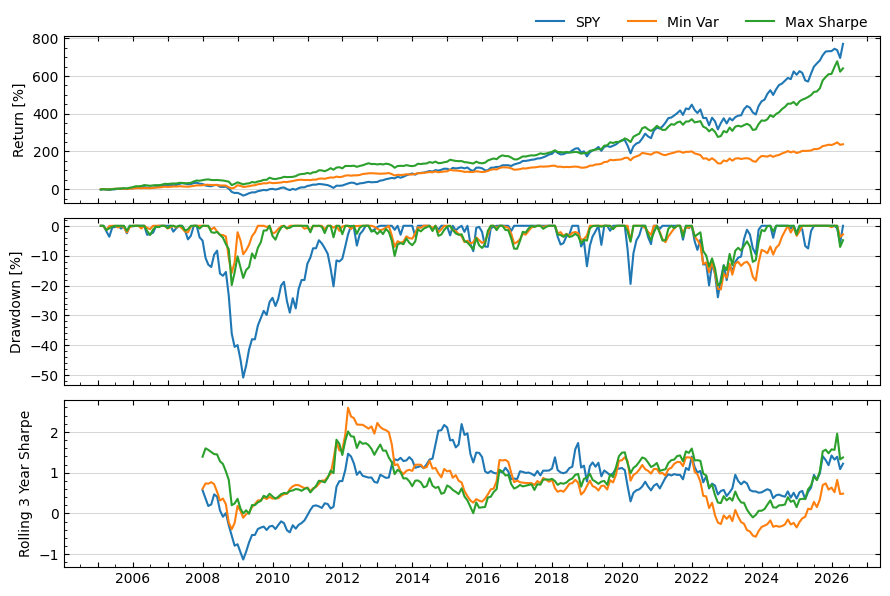

In [14]:
gmv_returns = returns_monthly.mul(pd.Series(gmv_weights)).sum(axis=1)
gmv_returns = pd.DataFrame(gmv_returns, columns=['Min Var'])

sharpe_returns = returns_monthly.mul(pd.Series(sharpe_weights)).sum(axis=1)
sharpe_returns = pd.DataFrame(sharpe_returns, columns=['Max Sharpe'])

portfolio_df = returns_monthly[['SPY']].copy()
portfolio_df = portfolio_df.join(gmv_returns)
portfolio_df = portfolio_df.join(sharpe_returns)

_ = performance_report(portfolio_df, risk_free_returns=rfr_monthly)

In [16]:
frontier = build_efficient_frontier(mean_returns, cov_matrix, n_points=500)

# random long-only portfolios, for visual context around the frontier
n_random       = 5_000
random_weights = np.random.dirichlet(np.ones(len(universe)), size=n_random)
random_returns = random_weights @ mean_returns.values
random_vols    = np.sqrt(np.einsum('ij,jk,ik->i', random_weights, cov_matrix.values, random_weights))

### Plotting the Frontier

Individual assets, the efficient frontier, a cloud of random long-only portfolios (to show the frontier actually dominates arbitrary weightings), the Global Minimum Variance and Max Sharpe portfolios, the hand-built 60/40 SPY/LQD portfolio from earlier, and the Capital Market Line anchored at the BIL risk-free rate.

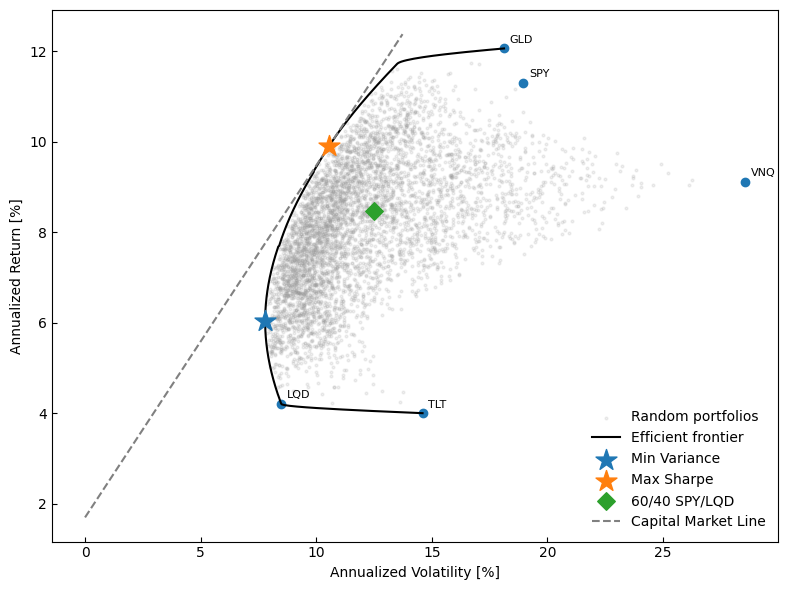

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(random_vols * 100, random_returns * 100, s=4, alpha=0.15, color='0.6', label='Random portfolios')
ax.plot(frontier['volatility'] * 100, frontier['target_return'] * 100, color='k', label='Efficient frontier')

for ticker in universe:
    vol = np.sqrt(cov_matrix.loc[ticker, ticker]) * 100
    ret = mean_returns[ticker] * 100
    ax.scatter(vol, ret, color='tab:blue')
    ax.annotate(ticker, (vol, ret), textcoords='offset points', xytext=(4, 4), fontsize=8)

ax.scatter(gmv_vol * 100, gmv_return * 100, marker='*', s=250, color='tab:blue', zorder=5, label='Min Variance')
ax.scatter(sharpe_vol * 100, sharpe_return * 100, marker='*', s=250, color='tab:orange', zorder=5, label='Max Sharpe')

sixty_forty_weights          = pd.Series(portfolio_weights).reindex(universe).fillna(0.)
sixty_forty_return, sixty_forty_vol = get_portfolio_stats(sixty_forty_weights, mean_returns, cov_matrix)
ax.scatter(sixty_forty_vol * 100, sixty_forty_return * 100, marker='D', s=80, color='tab:green', zorder=5, label='60/40 SPY/LQD')

cml_x = np.array([0, sharpe_vol * 1.3])
cml_y = rf_rate + (sharpe_return - rf_rate) / sharpe_vol * cml_x
ax.plot(cml_x * 100, cml_y * 100, linestyle='--', color='gray', label='Capital Market Line')

ax.set_xlabel('Annualized Volatility [%]')
ax.set_ylabel('Annualized Return [%]')
ax.legend(loc='lower right', frameon=False)

fig.tight_layout()
plt.show()

### Aside: Covariance Shrinkage

The sample covariance matrix above is itself a noisy estimate, especially with several correlated assets and a limited history. A common, cheap fix is to shrink it toward a more structured target (Ledoit-Wolf shrinkage Mosek 4.2.1). This trades off a bit of bias for a meaningful reduction in estimation error, which tends to make the Min Variance portfolio less sensitive to sampling noise.

## Add formula here and explain what you are shrinking towards
## Not sure if this is needed... Just say that there is lots of noise in covariance and especially in the mean return estimates

In [24]:
from sklearn.covariance import LedoitWolf

shrunk_cov = pd.DataFrame(LedoitWolf().fit(returns_daily[universe]).covariance_ * 12,
                          index=universe, columns=universe)

gmv_weights_shrunk        = solve_min_variance(mean_returns, shrunk_cov)
gmv_return_shrunk, gmv_vol_shrunk = get_portfolio_stats(gmv_weights_shrunk, mean_returns, shrunk_cov)

comparison_df = pd.DataFrame({'Sample Cov [%]' : gmv_weights * 100,
                              'Shrunk Cov [%]'  : gmv_weights_shrunk * 100,
                              }).round(1)

print('Portfolio Weights:')
print(comparison_df)
print()
print(f'Sample cov GMV volatility: {gmv_vol * 100:.2f}%')
print(f'Shrunk cov GMV volatility: {gmv_vol_shrunk * 100:.2f}%')

Portfolio Weights:
        Sample Cov [%]  Shrunk Cov [%]
Ticker                                
SPY               12.9            15.5
VNQ                0.0             1.8
GLD               11.8            23.2
LQD               65.0            28.9
TLT               10.3            30.5

Sample cov GMV volatility: 7.79%
Shrunk cov GMV volatility: 1.86%


                CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
-------------------------------------------------------------------
SPY              10.68        14.87            -50.78        0.65  
Min Var           5.88         7.82            -21.30        0.55  
Max Sharpe        9.84         9.89            -19.94        0.83  
Min Var Shrunk    6.99         8.73            -22.70        0.63  


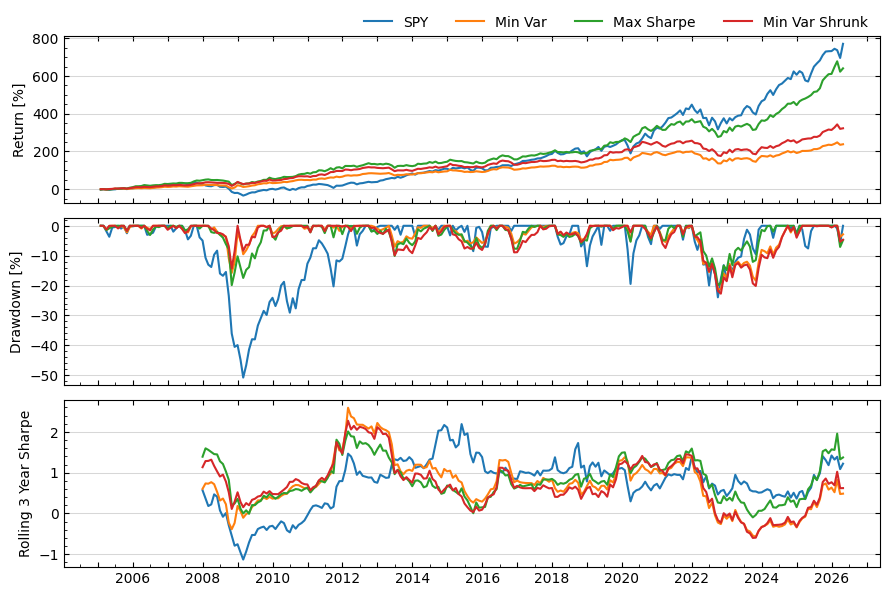

In [20]:
gmv_returns = returns_monthly.mul(pd.Series(gmv_weights)).sum(axis=1)
gmv_returns = pd.DataFrame(gmv_returns, columns=['Min Var'])

sharpe_returns = returns_monthly.mul(pd.Series(sharpe_weights)).sum(axis=1)
sharpe_returns = pd.DataFrame(sharpe_returns, columns=['Max Sharpe'])

gmv_returns_shrunk = returns_monthly.mul(pd.Series(gmv_weights_shrunk)).sum(axis=1)
gmv_returns_shrunk = pd.DataFrame(gmv_returns_shrunk, columns=['Min Var Shrunk'])

portfolio_df = returns_monthly[['SPY']].copy()
portfolio_df = portfolio_df.join(gmv_returns)
portfolio_df = portfolio_df.join(sharpe_returns)
portfolio_df = portfolio_df.join(gmv_returns_shrunk)

_ = performance_report(portfolio_df, risk_free_returns=rfr_monthly)

### Walk Forward Backtest
The Maximum Sharpe portfolio still underperforms just holding SPY. This is probably in part because the Sharpe ratio penalizes upwards volatility and downwards volatility equally. So max Sharpe just gives a good balance of return vs volatility, doesn't consider the upward spikes are in theory good. All that being said, this isn't a really practical comparison because the optimized portfolios are using data from the future to construct the optimal portfolio weights. To see if portfolio rebalancing would actually work in practice we can run a walk forward backtest.

Each month we will rebalance the portfolio based on a mean-variance optimization. We can use a 5 year lookback window to estimate the mean returns and covariance.

In [30]:
from dateutil.relativedelta import relativedelta

def walk_forward_weights(returns_monthly, returns_daily, rfr_monthly, universe,
                          lookback_years=5, strategy='max_sharpe'):
    '''
    Compute optimal portfolio weights for each month using only data strictly
    before that month (no lookahead). Returns a DataFrame of weights indexed
    by month-end date, aligned with returns_monthly so weights can be applied
    directly to that month's return.

    Parameters
    ----------
    returns_monthly : monthly returns DataFrame (month-end index)
    returns_daily   : daily returns DataFrame
    rfr_monthly     : monthly risk-free rate DataFrame (RF column)
    universe        : list of tickers
    lookback_years  : years of history to use for mean and covariance estimation
    strategy        : 'max_sharpe' or 'min_variance'
    '''
    min_months = int(lookback_years * 12 * 0.9)  # require at least 90% of expected observations
    records    = []

    for date in returns_monthly.index:
        window_start = date - relativedelta(years=lookback_years)

        # strictly before the current date — no lookahead
        monthly_window = returns_monthly.loc[
            (returns_monthly.index >= window_start) & (returns_monthly.index < date), universe
        ]
        daily_window = returns_daily.loc[
            (returns_daily.index >= window_start) & (returns_daily.index < date), universe
        ]
        rfr_window = rfr_monthly.loc[
            (rfr_monthly.index >= window_start) & (rfr_monthly.index < date)
        ]

        if len(monthly_window) < min_months:
            continue

        mean_returns = get_annualized_mean_return(monthly_window)
        cov_matrix   = daily_window.cov() * 252
        rf_rate      = rfr_window['RF'].mean() * 12

        try:
            if strategy == 'max_sharpe':
                weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)
            elif strategy == 'min_variance':
                weights = solve_min_variance(mean_returns, cov_matrix)
            else:
                raise ValueError(f'Unknown strategy: {strategy}')
        except RuntimeError:
            continue

        record         = weights.to_dict()
        record['date'] = date
        records.append(record)

    return pd.DataFrame(records).set_index('date')

               CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
------------------------------------------------------------------
SPY             10.83        15.64            -50.78        0.65  
Max Sharpe       9.60        10.32            -19.94        0.82  
Min Var          5.93         8.24            -21.30        0.58  
WF Max Sharpe   10.28        11.09            -23.27        0.83  
WF Min Var       6.45         8.29            -21.97        0.64  


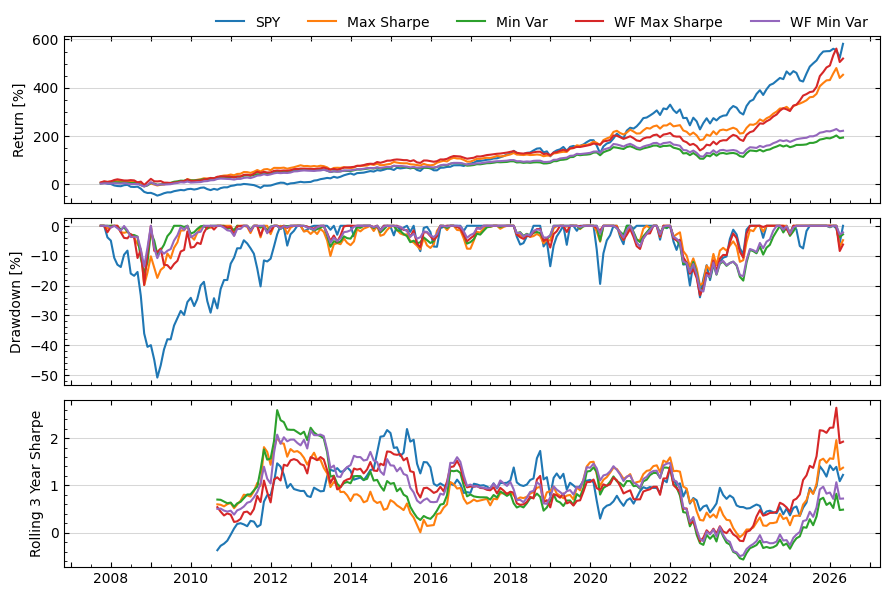

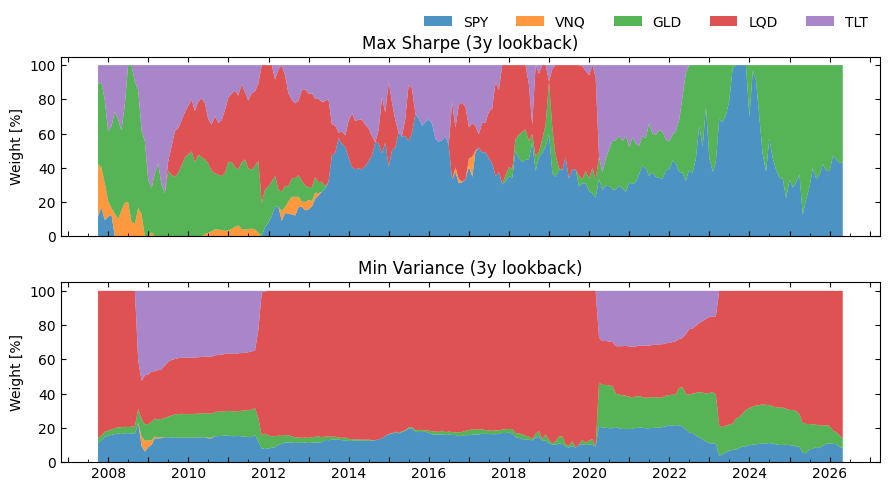

In [32]:
LOOKBACK_YEARS = 3

wf_weights_sharpe = walk_forward_weights(returns_monthly, returns_daily, rfr_monthly,
                                          universe, lookback_years=LOOKBACK_YEARS, strategy='max_sharpe')
wf_weights_gmv    = walk_forward_weights(returns_monthly, returns_daily, rfr_monthly,
                                          universe, lookback_years=LOOKBACK_YEARS, strategy='min_variance')

# min_count=1 ensures months with no weights (burn-in period) produce NaN rather than 0.0,
# so dropna() trims all series to the same start date
wf_returns_sharpe = (returns_monthly[universe] * wf_weights_sharpe).sum(axis=1, min_count=1).rename('WF Max Sharpe')
wf_returns_gmv    = (returns_monthly[universe] * wf_weights_gmv).sum(axis=1, min_count=1).rename('WF Min Var')

backtest_df = returns_monthly[['SPY']].join([sharpe_returns, gmv_returns, wf_returns_sharpe, wf_returns_gmv]).dropna()
_ = performance_report(backtest_df, risk_free_returns=rfr_monthly.loc[backtest_df.index])

# plot how weights evolved over time
fig, axs = plt.subplots(nrows=2, figsize=(9, 5), sharex=True)

for ax, weights_df, title in zip(axs,
                                  [wf_weights_sharpe, wf_weights_gmv],
                                  [f'Max Sharpe ({LOOKBACK_YEARS}y lookback)',
                                   f'Min Variance ({LOOKBACK_YEARS}y lookback)']):
    ax.stackplot(weights_df.index, [weights_df[t] * 100 for t in universe],
                 labels=universe, alpha=0.8)
    ax.set_ylabel('Weight [%]')
    ax.set_title(title)
    set_date_ticks(ax)
    ax.tick_params(top=True, bottom=True, left=True, right=True)

axs[0].legend(loc='upper right', bbox_to_anchor=(1, 1.3), ncols=len(universe), frameon=False)
fig.tight_layout()
plt.show()

Looks like walk-forward max sharpe outperforms the full dataset max sharpe... why?